## 1. Environment Setup and Libraries

This section handles mounting Google Drive for data access and importing necessary Python libraries such as pandas for data manipulation, numpy for numerical operations, and tensorflow for deep learning.

In [1]:
# setting up the libraries and google drive
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

Mounted at /content/drive


## 2. Dataset Loading and Extraction

Here, the DeepFashion dataset is loaded from Google Drive, including checking the file structure and extracting compressed image files to prepare them for processing.

In [2]:
# Checking what files are present in the main DeepFashion folder
BASE_PATH = "/content/drive/MyDrive/DeepFashion"

print("Files in project folder:")
print(os.listdir(BASE_PATH))

Files in project folder:
['Category and Attribute Prediction Benchmark-20260414T172424Z-3-001.zip', 'img-002.zip', 'Category and Attribute Prediction Benchmark']


In [3]:
# Extracting dataset zip file
import zipfile

zip_path = f"{BASE_PATH}/Category and Attribute Prediction Benchmark-20260414T172424Z-3-001.zip"
extract_path = f"{BASE_PATH}/Category and Attribute Prediction Benchmark"

# Checking if already extracted to avoid repeating work
if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(BASE_PATH)
    print("Extraction completed successfully")
else:
    print("Dataset already extracted, skipping step")

Dataset already extracted, skipping step


In [4]:
!cp "/content/drive/MyDrive/DeepFashion/img-002.zip" /content/

In [5]:
!unzip -q /content/img-002.zip -d /content/

In [6]:
# Defining clean and reusable paths for images and labels

IMG_PATH = "/content/img"

LABEL_FILE = f"{BASE_PATH}/Category and Attribute Prediction Benchmark/Anno_coarse/list_category_img.txt"

# Checking if paths exist correctly
print("Image folder exists:", os.path.exists(IMG_PATH))
print("Label file exists:", os.path.exists(LABEL_FILE))

Image folder exists: True
Label file exists: True


## 3. Data Preprocessing and Initial Filtering

This part focuses on cleaning the dataset by removing invalid image paths and then sampling a subset of the data for efficient model development, specifically targeting the top 10 categories.

In [7]:
# Load category annotation file

df = pd.read_csv(
    LABEL_FILE,
    sep=r'\s+',
    skiprows=2,
    names=["image", "category"]
    )

print("Annotation file loaded successfully")
df.head()

Annotation file loaded successfully


,image,category
0,img/Sheer_Pleated-Front_Blouse/img_00000001.jpg,3
1,img/Sheer_Pleated-Front_Blouse/img_00000002.jpg,3
2,img/Sheer_Pleated-Front_Blouse/img_00000003.jpg,3
3,img/Sheer_Pleated-Front_Blouse/img_00000004.jpg,3
4,img/Sheer_Pleated-Front_Blouse/img_00000005.jpg,3


In [8]:
# Convert relative image paths into full file paths

df["full_path"] = df["image"].apply(
    lambda x: f"{IMG_PATH}/{x.split('img/')[-1]}"
)

df.head()

,image,category,full_path
0,img/Sheer_Pleated-Front_Blouse/img_00000001.jpg,3,/content/img/Sheer_Pleated-Front_Blouse/img_00...
1,img/Sheer_Pleated-Front_Blouse/img_00000002.jpg,3,/content/img/Sheer_Pleated-Front_Blouse/img_00...
2,img/Sheer_Pleated-Front_Blouse/img_00000003.jpg,3,/content/img/Sheer_Pleated-Front_Blouse/img_00...
3,img/Sheer_Pleated-Front_Blouse/img_00000004.jpg,3,/content/img/Sheer_Pleated-Front_Blouse/img_00...
4,img/Sheer_Pleated-Front_Blouse/img_00000005.jpg,3,/content/img/Sheer_Pleated-Front_Blouse/img_00...


In [ ]:
# Check if image files actually exist

df["exists"] = df["full_path"].apply(os.path.exists)

print(df["exists"].value_counts())

In [ ]:
# remove invalid images
df["exists"] = df["full_path"].apply(os.path.exists)

df_clean = df[df["exists"] == True]

print("Clean dataset size:", len(df_clean))

In [ ]:
# sample 10,000
df_small = df_clean.sample(n=10000, random_state=42)

print("Final dataset size:", len(df_small))

In [ ]:
# top 10
top_classes = df_clean["category"].value_counts().index[:10]
df_filtered = df_clean[df_clean["category"].isin(top_classes)]
df_small = df_filtered.groupby("category").apply(
    lambda x: x.sample(1000, random_state=42)
).reset_index(drop=True)
print("Number of classes:", df_small["category"].nunique())

## 4. Label Encoding

Categories are converted from textual names to numerical labels using `LabelEncoder`. This is a necessary step for training classification models.

In [ ]:
df_small["category"].value_counts()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_small["label_encoded"] = le.fit_transform(df_small["category"])

print("Label encoding completed")
df_small[["category", "label_encoded"]].head()

In [ ]:
df_small["label_encoded"].value_counts()

In [ ]:
print("Unique labels:", df_small["label_encoded"].nunique())

## 5. Image Loading and Preprocessing

This section defines a utility function to load, resize, and normalize image data, preparing it for consistent input into the neural network.

In [ ]:
# Define image loading and preprocessing function

import tensorflow as tf

IMG_SIZE = (224, 224)

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = image / 255.0
    return image, label

## 6. Dataset Preparation and Train-Test Split

The cleaned data paths and labels are prepared, and then the dataset is divided into training and testing sets to ensure robust model evaluation.

In [ ]:
f_small = df_small.reset_index(drop=True)

paths = df_small["full_path"].values
labels = df_small["label_encoded"].values

assert len(paths) == len(labels)

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

dataset = dataset.shuffle(buffer_size=len(paths))

dataset = dataset.batch(32)

dataset = dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
print(len(paths))
print(len(labels))
print(df_small.shape)

In [ ]:
from sklearn.model_selection import train_test_split

train_paths, test_paths, train_labels, test_labels = train_test_split(
    paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

## 7. TensorFlow Dataset Creation

The training and testing data are converted into optimized `tf.data.Dataset` objects, allowing for efficient loading, shuffling, batching, and prefetching during model training.

In [41]:
import tensorflow as tf

# train dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))

train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(1000)

train_ds = train_ds.batch(16)   # IMPORTANT: reduce batch size

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

In [42]:
import tensorflow as tf

# test dataset
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

test_ds = test_ds.batch(16)

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

## 8. CNN Model Architecture

A custom Convolutional Neural Network (CNN) model is defined for image classification, featuring convolutional layers, pooling layers, and dense layers for feature learning and classification.

In [43]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

## 9. Model Compilation

The CNN model is compiled with an Adam optimizer, sparse categorical crossentropy loss, and accuracy as the primary metric, preparing it for the training process.

In [44]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 10. Callbacks

An EarlyStopping callback is configured to monitor validation loss, preventing overfitting by stopping training if validation performance does not improve after a set number of epochs.

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 11. Model Training

The compiled CNN model is trained on the prepared training dataset, with its performance monitored on the validation set, leveraging early stopping to optimize training duration.

In [46]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 155ms/step - accuracy: 0.1124 - loss: 2.3000 - val_accuracy: 0.1330 - val_loss: 2.2894
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.1341 - loss: 2.2786 - val_accuracy: 0.1360 - val_loss: 2.2765
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.1475 - loss: 2.2614 - val_accuracy: 0.1415 - val_loss: 2.2626
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - accuracy: 0.1579 - loss: 2.2486 - val_accuracy: 0.1580 - val_loss: 2.2685
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.1660 - loss: 2.2362 - val_accuracy: 0.1705 - val_loss: 2.2403
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step - accuracy: 0.1795 - loss: 2.2195 - val_accuracy: 0.1750 - val_loss: 2.2381
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step - accuracy: 0.1879 - loss: 2.1998 - val_accuracy: 0.2070 - val_loss: 2.2062
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.2050 - loss: 2

## 12. Model Saving

The trained model's weights and architecture are saved to a file, allowing for later reloading and deployment without needing to retrain.

In [47]:
model.save("cnn_fashion_model.h5")

## 13. Performance Visualization (Training History)

This section visualizes the model's training and validation accuracy and loss over epochs, providing insights into its learning progress and potential overfitting.

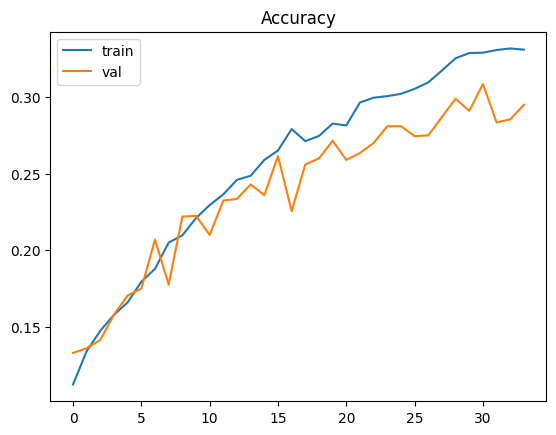

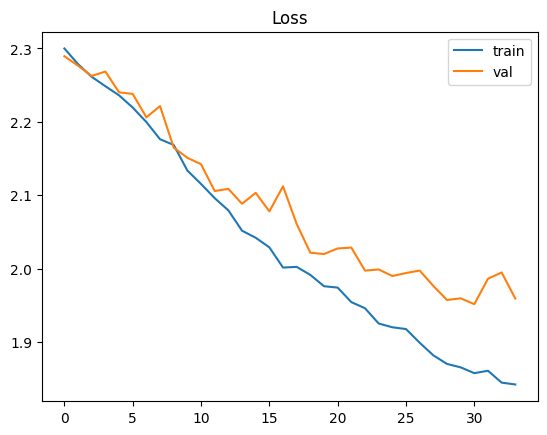

In [48]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

## 14. Model Evaluation (Classification Report)

The model's performance on the test dataset is quantitatively assessed using a classification report, detailing precision, recall, and F1-score for each category.

In [49]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━

## 15. Sample Training Images

This section displays a grid of sample images from the training dataset along with their labels, providing a visual confirmation of the data being fed to the model.

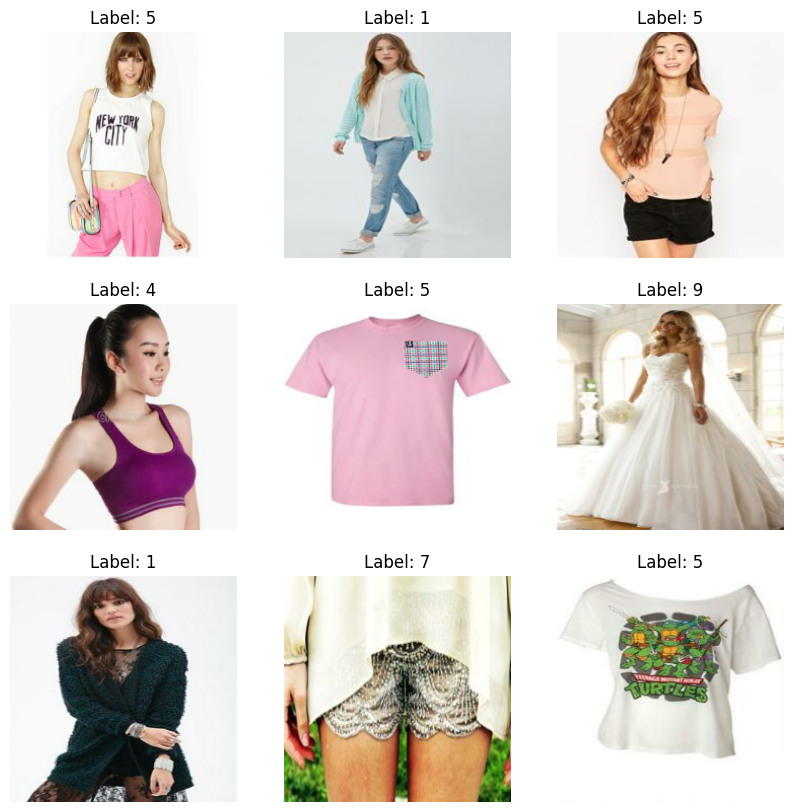

In [50]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis('off')

    plt.show()

## 16. Personality Mapping

A dictionary is defined to map the numerical category labels back to descriptive fashion personality names, enhancing the interpretability of model predictions.

In [51]:
personality_map = {
    0: "Minimalist",
    1: "Casual",
    2: "Elegant",
    3: "Sporty",
    4: "Chic",
    5: "Comfort",
    6: "Simple",
    7: "Bold",
    8: "Trendy",
    9: "Creative"
}

## 17. Visualizing Sample Predictions

This section displays sample images from the test set with their predicted and true labels, offering a qualitative assessment of the model's prediction accuracy and misclassifications.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


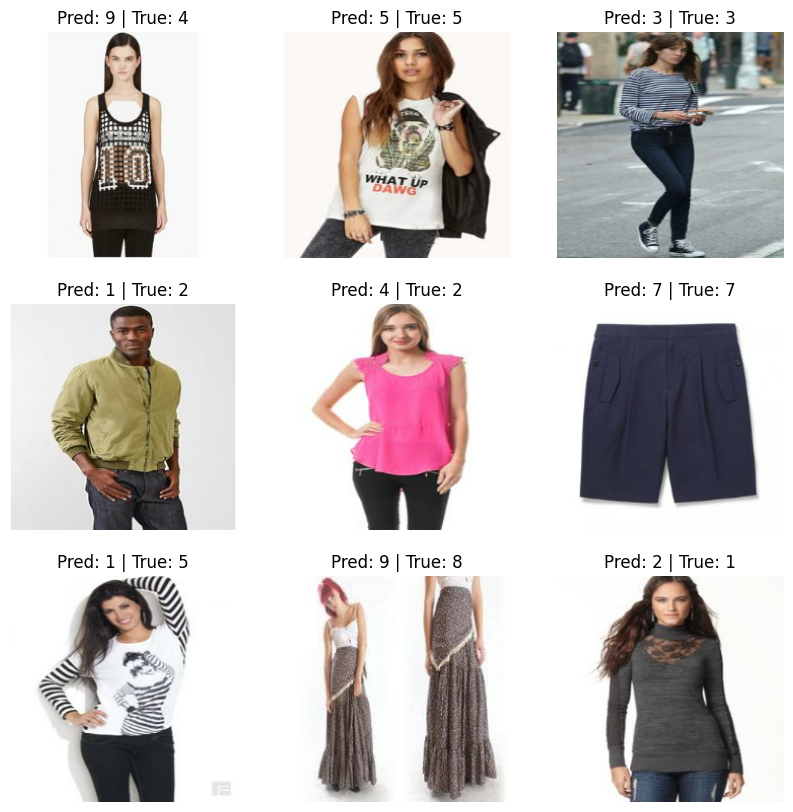

In [52]:
for images, labels in test_ds.take(1):
    preds = model.predict(images)
    pred_classes = np.argmax(preds, axis=1)

    plt.figure(figsize=(10,10))

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])

        plt.title(f"Pred: {pred_classes[i]} | True: {labels[i].numpy()}")
        plt.axis('off')

    plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


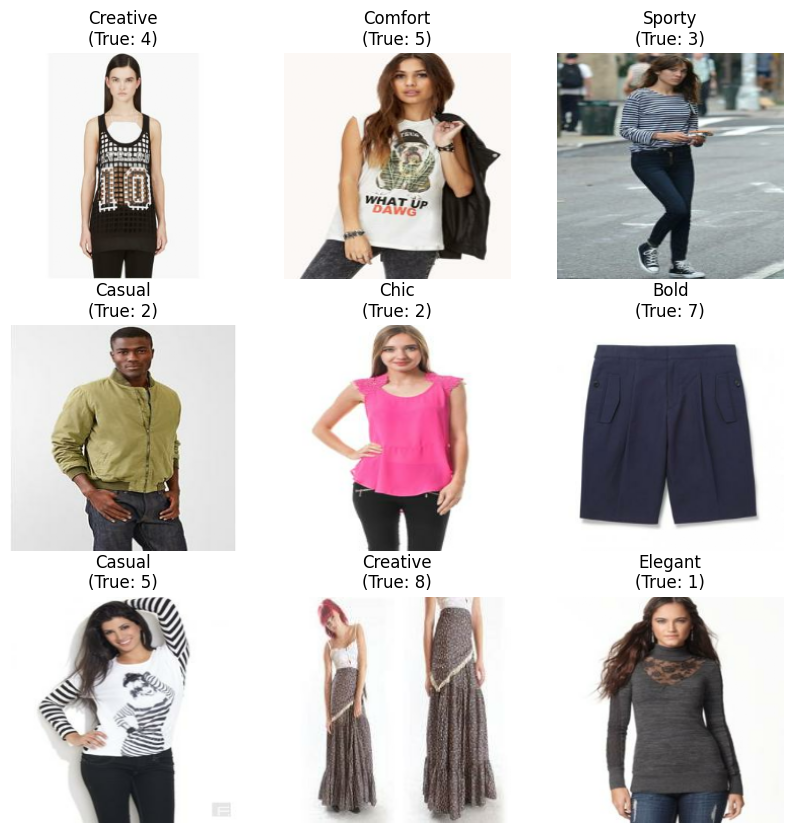

In [53]:
for images, labels in test_ds.take(1):
    preds = model.predict(images)
    pred_classes = np.argmax(preds, axis=1)

    plt.figure(figsize=(10,10))

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])

        pred = pred_classes[i]
        personality = personality_map[pred]

        plt.title(f"{personality}\n(True: {labels[i].numpy()})")
        plt.axis('off')

    plt.show()

## 18. Confusion Matrix Visualization

A heatmap of the confusion matrix is generated to visually represent the model's classification performance, highlighting correct predictions and common misclassifications between categories.

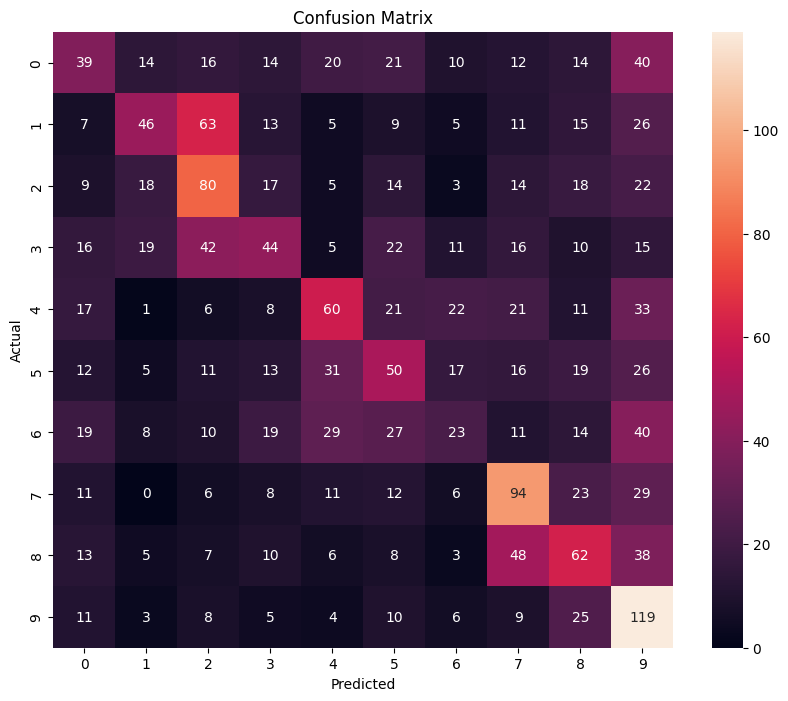

In [54]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 19. UMAP Library Installation

The `umap-learn` library is installed to enable Uniform Manifold Approximation and Projection for dimensionality reduction, a technique used for visualizing high-dimensional data.

In [56]:
  !pip install umap-learn

## 20. Feature Extraction

Features are extracted from an intermediate layer of the trained CNN model using a new `feature_extractor` model. These features represent the model's learned representations of the images.

In [57]:
for images, labels in train_ds.take(1):
    _ = model(images)

In [58]:
feature_extractor = tf.keras.Model(
    inputs=model.layers[0].input,
    outputs=model.layers[-3].output
)

In [59]:
features = []
labels_list = []

for images, labels in test_ds:
    feat = feature_extractor.predict(images)
    features.append(feat)
    labels_list.append(labels.numpy())

features = np.concatenate(features)
labels_list = np.concatenate(labels_list)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━

## 21. UMAP Projection Visualization

The extracted high-dimensional features are reduced to a 2D embedding using UMAP, and then visualized to assess the separability of different fashion categories in the learned feature space.

In [60]:
import umap

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(features)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


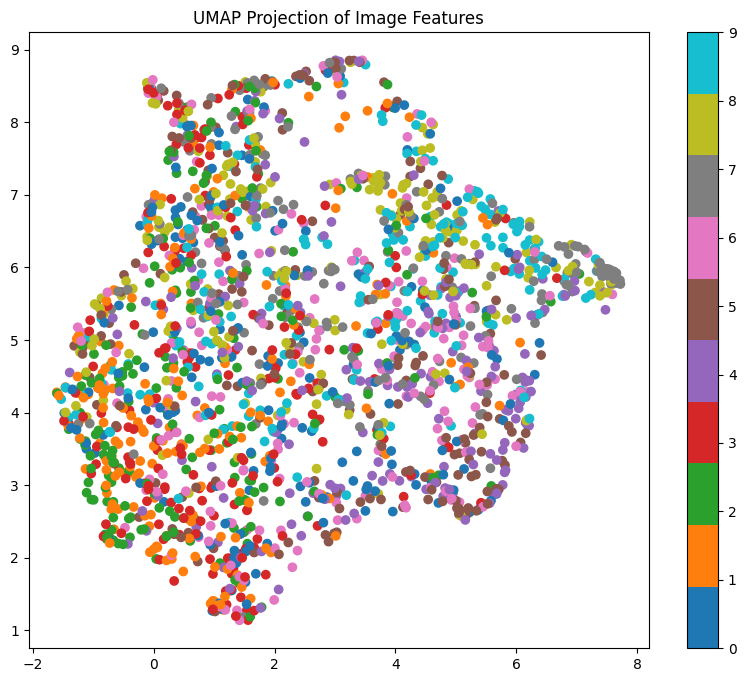

In [61]:
plt.figure(figsize=(10,8))
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=labels_list,
    cmap='tab10'
)

plt.colorbar(scatter)
plt.title("UMAP Projection of Image Features")
plt.show()